# AB Test Experiment Report

**Team 13:** Shuxuan Xu(sx2412), Justine Dugger-Ades(gad2154), Yumeng Xu(yx2982), Shreaya Amalapurapu(sa4342)

**Github Repository:** [https://github.com/xsxsx-999/5243-project3-T13](https://github.com/xsxsx-999/5243-project3-T13)

**Launched URL**:  [https://xsxsx-999.github.io/random-url-for-AB-test-5243/](https://xsxsx-999.github.io/random-url-for-AB-test-5243/)

## 1. Introduction & Research Question

Designed for STATGR5243, this project establishes a robust framework for conducting data-driven A/B testing. We developed an interactive data-cleaning platform via ShinyApps and instrumented it with Google Analytics for precise telemetry collection. The core of the project culminates in a full-scale A/B test, transitioning from experimental design to the statistical analysis of real-world user data to evaluate platform efficiency.

**Research Question:**
Does altering the navigation UI (tabs bars vs. next buttons) significantly impact a user's task efficiency (measured by time) and their subjective rating of the application? 

**Objective:**
By simulating a "mini-game" challenge environment, we aim to quantitatively identify which UI variant provides a smoother user experience, thereby informing the final design of the app.

## 2. Experimental Design & Methodology

### 2.1 Research Goal
This experiment was designed to evaluate whether different **workflow navigation** structures affect user experience and task completion in our data processing application. Specifically, we compared two distinct workflow navigation interfaces to examine their impact on clarity, speed, and the overall ease of completing data preparation steps.

### 2.2 Formal Hypotheses
We treat **two primary endpoints** separately (each with its own null and a pre-specified directional alternative):

**Efficiency (total workflow time)**
- $H_{0,\text{time}}$: $\mu_{A,\text{time}} = \mu_{B,\text{time}}$
- $H_{1,\text{time}}$: $\mu_{A,\text{time}} < \mu_{B,\text{time}}$ (Version A is faster)

**Usability (end-of-session rating)**
- $H_{0,\text{rating}}$: $\mu_{A,\text{rating}} = \mu_{B,\text{rating}}$
- $H_{1,\text{rating}}$: $\mu_{A,\text{rating}} > \mu_{B,\text{rating}}$ (Version A is rated higher)

Here $\mu$ denotes a population mean for users assigned to Version A vs Version B. **Per-task timing tests** (Section 4.3) are **exploratory** diagnostics (multiple comparisons) and are not additional confirmatory hypotheses.

### 2.3 Treatment Groups (UI Variants)
To test our hypotheses, we engineered two distinct versions of the application:
* **Version A (Top-Tab Navigation):** Utilized a top-tab layout where users could directly move between processing stages (e.g., data upload, cleaning, feature engineering, EDA, and export). This design afforded users higher flexibility, allowing them to freely revisit previous steps or jump between sections.

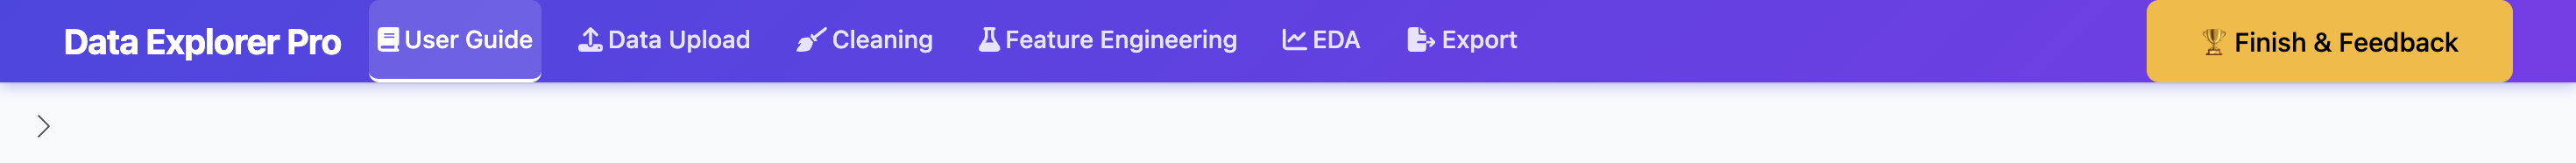

* **Version B (Linear Workflow):** Employed a sequential workflow design utilizing "Next" and "Back" buttons. This interface guided users through the data processing procedure in a highly structured, step-by-step manner.

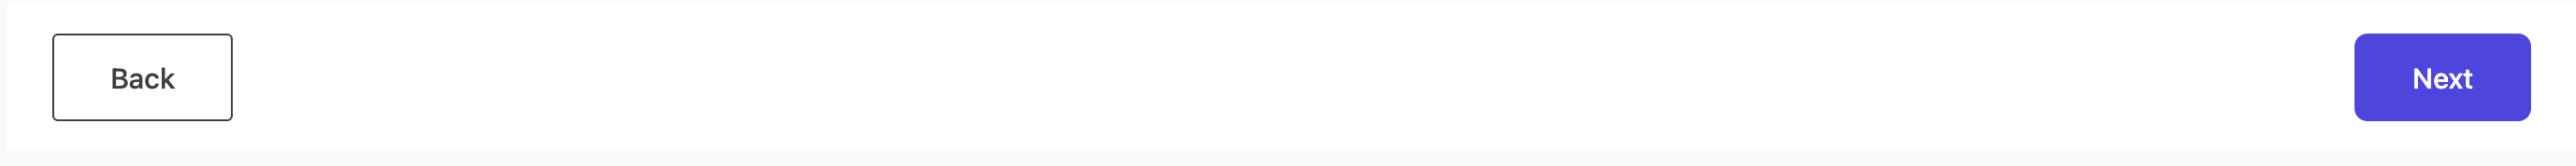

### 2.4 Methodology & Randomization Strategy
To ensure a robust controlled A/B test and preserve the internal validity of the experiment, we implemented the following routing and consistency protocols during the launch phase:
1. **Random Assignment & Routing:** A random assignment mechanism was introduced at the entry point of the system. A redirect URL dynamically routed users to one of the two separately deployed application versions, which were hosted in different repositories.
2. **Session Consistency (Local Storage):** To prevent users from accidentally switching between versions across sessions (or upon page refreshes), we utilized local storage. This ensured that each user remained locked into their initially assigned version.

This technical setup guaranteed three critical experimental conditions: each participant experienced only one interface condition, the assignment was strictly random, and user traffic was distributed as evenly as possible across both Version A and Version B.

## 3. Data Collection & Process

### 3.1 Custom Variables Documentation
To support the A/B test and evaluate how different workflow designs influence user behavior, original behavioral data was collected through custom Google Analytics (GA) event tracking embedded directly within the application.

#### 3.1.1 Event Tracking Architecture
Rather than relying on basic page views, we configured granular custom events to capture user interactions accurately. The tracking was built around three primary event types:
* `task_completed`: Triggered when a user successfully finishes a specific challenge.
* `session_completed`: Triggered when a user successfully finishes the entire data-processing pipeline.
* `session_abandoned`: Triggered if a user drops out before completing all tasks.

#### 3.1.2 Telemetry & Custom Variables
Each event captured a set of custom parameters mapped to GA custom dimensions and metrics. The selection of these variables was carefully designed to evaluate both workflow efficiency and user experience:

**a. Identifiers & Grouping:**
* **`ab_test_id` (UUID/My Session ID):** A unique identifier assigned to each user session. This ensures all actions performed by the same user are linked together, allowing us to reconstruct complete user journeys across events without collecting Personally Identifiable Information (PII).
* **`app_version`:** Indicates whether the user was assigned to Version A or Version B, which is essential for the fundamental A/B comparison.

**b. Task-Level Metrics:**
* **`task_id` & `time_spent_seconds`:** Records which specific step the user is on and the exact duration spent on it. This provides deep insights into usability, allowing us to pinpoint exact workflow bottlenecks and calculate efficiency.

**c. Session-Level Outcome Metrics:**
* **`tasks_completed` & `tasks_completed_at_dropout`:** Measures the total progression of the user and their dropout behavior. This reflects overall workflow success and user engagement levels.

**d. Qualitative Metrics:**
* **`rating`:** Captures the user's subjective evaluation of the experience at the end of the session, which complements the quantitative behavioral data with subjective feedback, offering a comprehensive assessment of interface performance.

#### 3.1.3 Data Quality & Integrity
To ensure high-quality, reliable analysis, several data integrity protocols were implemented:
* **Mapping Documentation:** The mapping between code-level variables and their corresponding GA representations was carefully documented to prevent naming convention errors between the implementation and analytics platforms.
* **Controlled Collection Window:** A fixed data collection period was defined to avoid mixing experimental data with earlier beta-test data, with sufficient time allowed to account for standard GA data processing delays. This ensured the final dataset was well-structured and strictly aligned with the experimental design.

### 3.2 Collection & Processing

After exporting the raw tracking data from Google Analytics, we implemented a targeted data cleaning pipeline to ensure the reliability of our A/B testing metrics. The processing phase focused on three critical steps:

#### 3.2.1 Data Segmentation (Event-Based vs. User-Based)
To facilitate different levels of statistical analysis, the single raw dataset was deliberately split into two distinct, structured datasets:
* **Event-Based Dataset:** Contains granular, step-by-step tracking. Each row represents a specific action (e.g., completing a single task), allowing us to analyze micro-interactions, bottleneck tasks, and exact task durations.
* **User-Based Dataset:** Aggregates performance at the individual user level. Each row represents a single user's complete session, summarizing overarching metrics like total tasks completed, total time spent, and their final subjective rating.

#### 3.2.2 Filtering Invalid Sessions
During the initial data review, we identified tracking entries where the UUID(My Session ID) was missing or registered as `(not set)`. These anomalies were likely caused by accidental drops-ins or automated system pings generated when we had to switch application deployment URLs due to ShinyApps server usage limitations. To maintain strict user-level consistency and prevent noise, we filtered out these anomalies, extracting only valid rows with definitive session identifiers.

#### 3.2.3 Quality Thresholds
Excluded aggregated rows by enforcing `Total users == 1`, and applied a minimum time threshold to filter out accidental clicks or bot traffic.

#### 3.2.4 Final Dataset Output
Following the normalization pipeline, the fully cleaned dataset consisted of **421 valid event rows** representing **74 unique users**. The traffic distribution remained well-balanced and suitable for comparative analysis, with **38 users in Version A** and **36 users in Version B**.

## 4. Statistical Analysis & Results

### 4.1 Methods
For each **primary** user-level endpoint we report:
- **Welch’s t-test** (unequal variances) with a **two-sided** normal-approximation *p*-value ($p_{two}$)
- A **one-sided** normal-approximation *p*-value ($p_{dir}$) that matches the **pre-specified directional** alternatives in Section 2.2
- **Bootstrap 95% CI** for the mean difference ($\bar{A}-\bar{B}$) using settings `BOOTSTRAP_ITERS=20000`, `BOOTSTRAP_SEED=7`
- **Cohen’s $d$** (standardized mean difference)

For **exploratory** per-task tests, we still use two-sided Welch tests but interpret nominal thresholds cautiously due to **multiple comparisons** (see Section 4.3 and Section 5).

### 4.2 Primary results (user-level)
The table below summarizes the two confirmatory endpoints on the cleaned user-level dataset ($n_A=38$, $n_B=36$). 

| Endpoint | A mean | B mean | Mean diff (A−B) | Bootstrap 95% CI for diff | Cohen’s d | $p_{two}$ | $p_{dir}$ |
|---|---:|---:|---:|---|---:|---:|---:|
| Total time (seconds) | 315.52 | 611.96 | −296.44 | [−525.80, −90.55] | −0.624 | 0.008365 | 0.004183 |
| Rating (1–5) | 4.184 | 2.639 | 1.545 | [1.080, 2.007] | 1.504 | 1.183e-10 | 5.914e-11 |

**Decision (α = 0.05, directional):** For total time, the observed direction matches $H_{1,\text{time}}$ (A faster) and $p_{dir} < 0.05$. For rating, the observed direction matches $H_{1,\text{rating}}$ (A higher) and $p_{dir} \ll 0.05$. The two-sided *p*-values are consistent with these conclusions.

On average, Version B’s total workflow time is about **1.94×** Version A’s in this sample (611.96 / 315.52), which motivates the “~doubling” language in the interpretation section.

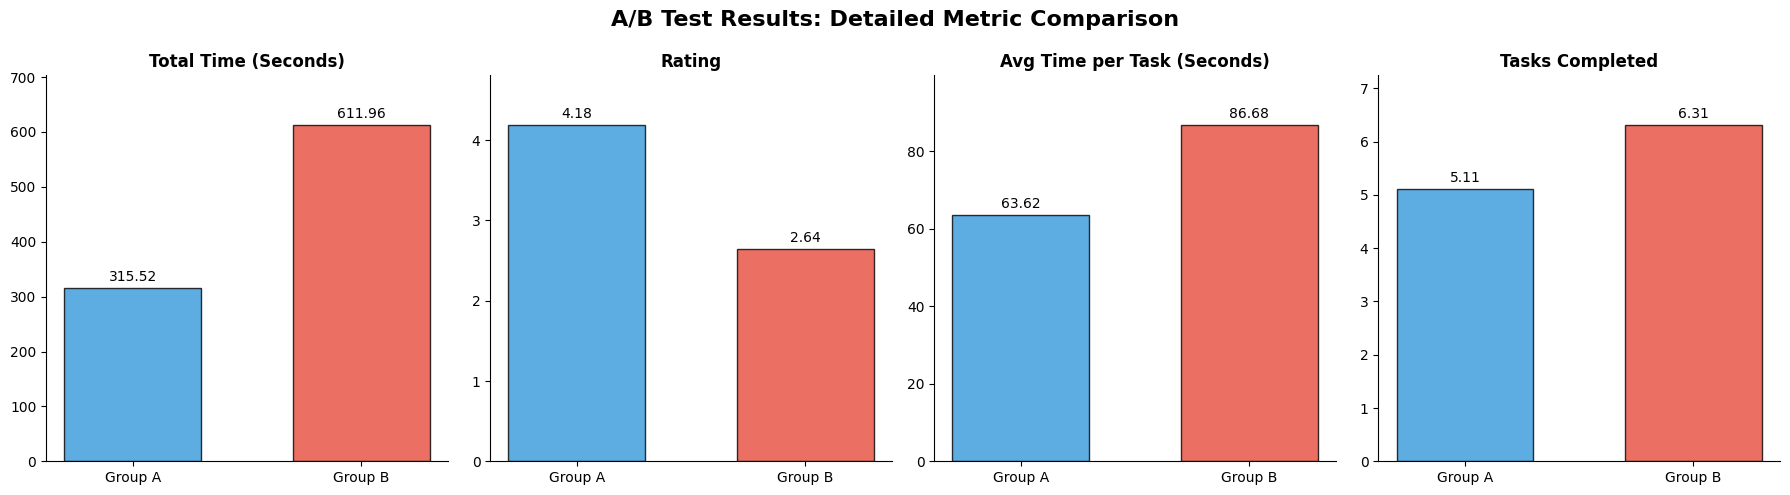

### 4.3 Exploratory per-task drill-down (multiple comparisons)
To localize friction, we ran Welch tests on `time_spent_seconds` for Tasks 1–11. These tests are **not** independent confirmatory claims unless multiplicity is addressed; along with a conservative **Bonferroni** flag at $\alpha=0.05/k$.

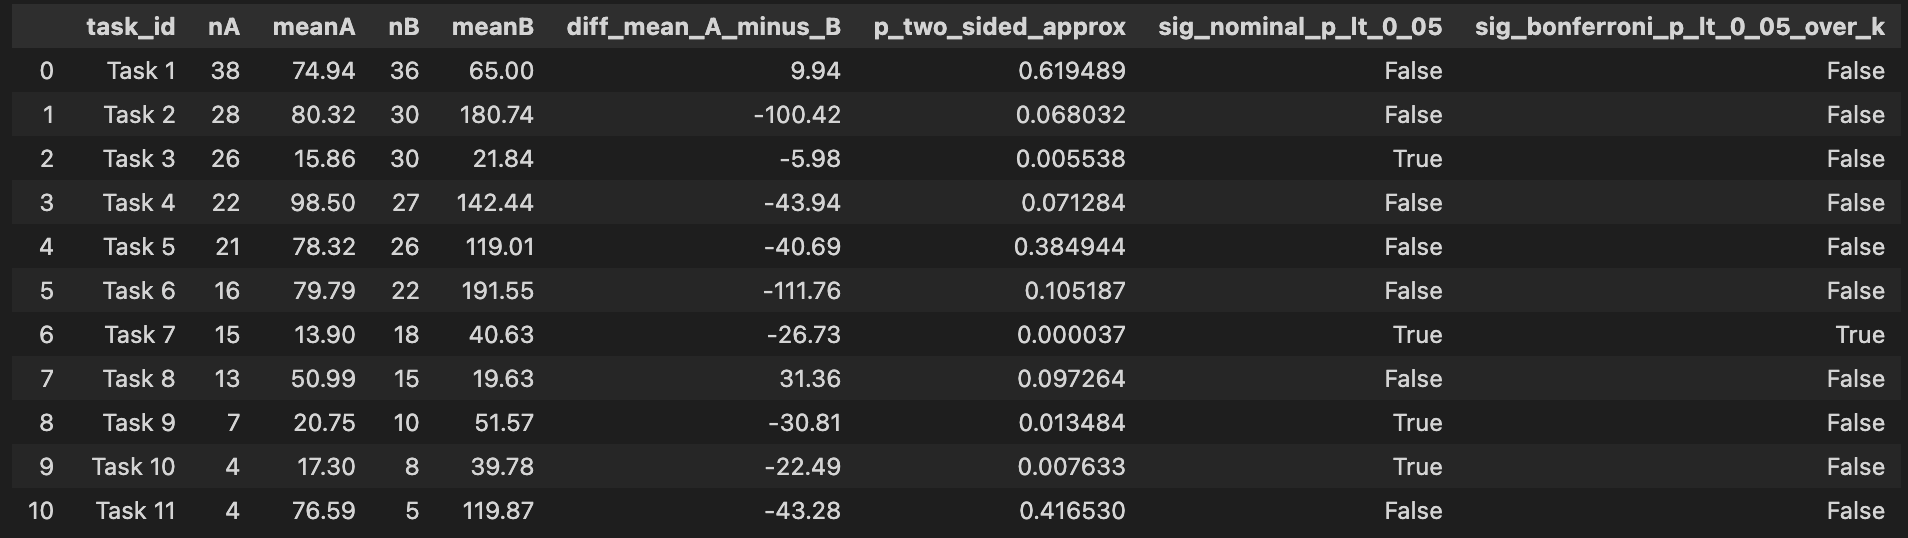

**Key observations (same qualitative story as before):**
* **Pervasive friction:** In 9 of 11 tasks, Version A’s mean completion time is faster than Version B’s (negative `diff_mean_A_minus_B`).
* **Nominal bottlenecks:** Tasks 3, 7, 9, and 10 show $p_{two}<0.05$ at the task level (interpret cautiously).
* **Task 7:** especially large separation (means roughly **13.90s vs 40.63s**; $p_two \approx 3.7e-5$ in our analysis run).
* **Large practical gaps without nominal significance:** Tasks 2 and 6 show very large mean gaps but can miss $p<0.05$ due to variance / effective sample size.

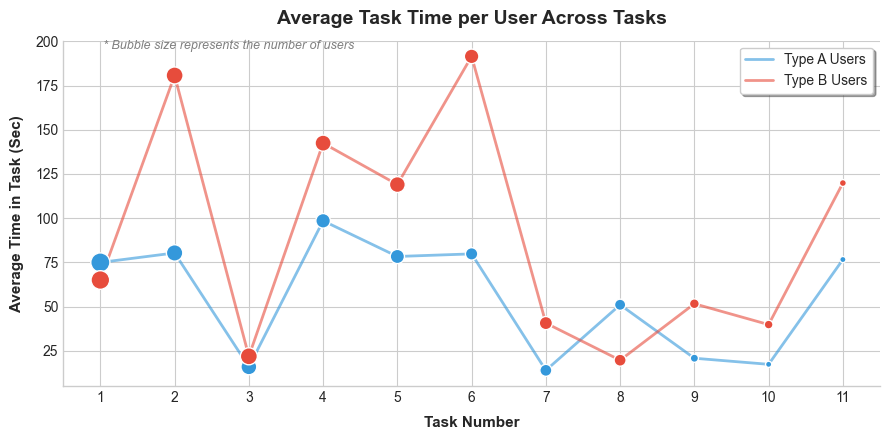

### 4.4 Interpretation & Conclusion
The statistical results provide convincing evidence that the interface layout fundamentally impacts user workflow, with Version A (top-tab navigation) demonstrating clear superiority.

The directional evidence for the two primary endpoints (Section 4.2), combined with the exploratory per-task breakdown (Section 4.3), supports a consistent story: Version B’s rigid sequential layout introduces widespread friction across many micro-steps, not a single isolated slowdown.

Because Version B substantially increases total time while reducing subjective ratings in this sample, it is a poor fit for a multi-step data-cleaning workflow compared with Version A’s flexible navigation.


## 5. Challenges & Limitations

While the A/B test yielded statistically significant results and clear directional insights, we must acknowledge several limitations and challenges that contextualize our findings. Identifying these constraints is crucial for interpreting the data accurately and guiding future iterations of the application.

* **Sample Selection Bias & Baseline Expertise:** The participant pool for this experiment may not perfectly represent the ultimate target demographic of the application. There is likely an inherent variance in the users' baseline data literacy and familiarity with standard data-cleaning concepts. Because users possessed varying levels of prior knowledge, some may have been learning the data concepts on the fly rather than purely evaluating the UI navigation. This variance introduces a degree of noise into the `time_spent_seconds` metric.

* **Shared Usability Ambiguities (Task Instructions):** Based on qualitative feedback and overarching time metrics, we identified that some workflow friction was independent of the A/B UI layouts. Users reported that certain feature descriptions, tooltips, and task instructions within the app were vague or overly technical. This shared ambiguity likely inflated the baseline completion times across *both* Version A and Version B. It highlights that while navigation layout is critical, the underlying explanatory text requires a modification to improve overall clarity.

* **Uncontrolled Testing Environments & Telemetry Constraints:** Because the application was deployed via ShinyApps and tested remotely, we could not control for hardware and environmental differences (e.g., variations in screen sizes, use of trackpads vs. external mice, or network latency). These external factors can significantly impact the speed of completing interactive data tasks.

* **Multiple Comparisons (Per-Task Tests):** Section 4.3 repeats hypothesis tests across tasks. Even under the global null, we expect some nominal $p<0.05$ findings by chance. We mitigate transparency risk by reporting Bonferroni-adjusted flags and by treating per-task results as exploratory diagnostics rather than independent confirmatory endpoints.


## Team Member Contributions:

* **Shuxuan Xu (sx2412):** Led the development and setup of Version A, integrated Google Analytics (GA) for custom event tracking, and managed the overarching data collection process.

* **Shreaya Amalapurapu (sa4342):** Led the development and setup of Version B, ensuring the linear sequential navigation logic and UI constraints were properly implemented for the experiment.

* **Justine Dugger-Ades (gad2154):** Conducted the statistical analysis for the A/B test, including data cleaning, hypothesis testing, and the granular per-task bottleneck evaluation.

* **Yumeng Xu (yx2982):** Authored and structured the final analytical report, synthesizing the methodology, statistical findings, and comprehensive UX insights.